# 10 — Train Text Model

Fine-tunes every model listed in `config.MODELS_TO_RUN` on the MELD training
set and saves the best checkpoint (by dev macro-F1) for each.

**Depends on:** `01_preprocess_text.ipynb` (run automatically below).

**Outputs** (written to `../experiments/text_unimodal/<version>/<model_slug>/`):
- `model/`               — best checkpoint (HuggingFace format)
- `history.csv`          — per-epoch train/dev metrics
- `config.json`          — full run config
- `train_metrics.json`   — training summary (params, time, power, best dev F1)
- `power_samples.csv`    — raw GPU power readings

In [1]:
# Run the preprocessing notebook — this sets train_df, dev_df, test_df,
# label2id, id2label, labels_sorted in this kernel's namespace.
%run 01_preprocess_text.ipynb

e:\Licenta\Multimodal-Emotion-Recognition---Bachelor-Thesis\.venv\Lib\site-packages\nbformat\__init__.py:96: MissingIDFieldWarning: Cell is missing an id field, this will become a hard error in future nbformat versions. You may want to use `normalize()` on your notebooks before validations (available since nbformat 5.1.4). Previous versions of nbformat are fixing this issue transparently, and will stop doing so in the future.
  validate(nb)
e:\Licenta\Multimodal-Emotion-Recognition---Bachelor-Thesis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Label map: {'anger': 0, 'disgust': 1, 'fear': 2, 'happiness': 3, 'neutral': 4, 'sadness': 5, 'surprise': 6}
Train: 9,989 | Dev: 1,109 | Test: 2,610
Dropped from dev (unseen labels): 0
Dropped from test (unseen labels): 0
[train] OK — 9,989 rows, dtypes: {'text': <StringDtype(na_value=nan)>, 'emotion': <StringDtype(na_value=nan)>, 'label': dtype('int32')}
[dev] OK — 1,109 rows, dtypes: {'text': <StringDtype(na_value=nan)>, 'emotion': <StringDtype(na_value=nan)>, 'label': dtype('int32')}
[test] OK — 2,610 rows, dtypes: {'text': <StringDtype(na_value=nan)>, 'emotion': <StringDtype(na_value=nan)>, 'label': dtype('int32')}


In [2]:
from src.config import MODELS_TO_RUN, DEVICE
from src.training.train import train_one

print('Device:', DEVICE)
print('Models to train:', MODELS_TO_RUN)

Device: cuda
Models to train: ['bert-base-uncased', 'distilbert-base-uncased']


## Train

Each call to `train_one` runs the full training loop and returns the path to
the run directory. Bump `config.VERSION` if you want a clean slate.

In [3]:
run_dirs = []

for model_name in MODELS_TO_RUN:
    run_dir = train_one(
        model_name=model_name,
        train_df=train_df,
        dev_df=dev_df,
        test_df=test_df,
        label2id=label2id,
        id2label=id2label,
    )
    run_dirs.append(run_dir)

print('\nAll run directories:')
for d in run_dirs:
    print(' ', d)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 1003.21it/s, Materializing param=bert.pooler.dense.weight]                              
BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those pa

No prgress in 1 epochs.


bert_base_uncased | epoch 5/200: 100%|██████████| 625/625 [00:49<00:00, 12.74it/s]
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.96it/s]
bert_base_uncased | epoch 6/200: 100%|██████████| 625/625 [00:50<00:00, 12.40it/s]
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.72it/s]
bert_base_uncased | epoch 7/200: 100%|██████████| 625/625 [00:49<00:00, 12.70it/s]
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.17it/s]
bert_base_uncased | epoch 8/200: 100%|██████████| 625/625 [00:48<00:00, 12.87it/s]
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.96it/s]
bert_base_uncased | epoch 9/200: 100%|██████████| 625/625 [00:48<00:00, 12.80it/s]
Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.19it/s]
bert_base_uncased | epoch 10/200: 100%|██████████| 625/625 [00:48<00:00, 12.78it/s]


No prgress in 1 epochs.


bert_base_uncased | epoch 11/200: 100%|██████████| 625/625 [00:51<00:00, 12.24it/s]


...

No prgress in 3 epochs.


distilbert_base_uncased | epoch 16/200: 100%|██████████| 625/625 [00:28<00:00, 21.84it/s]


No prgress in 4 epochs.


distilbert_base_uncased | epoch 17/200: 100%|██████████| 625/625 [00:28<00:00, 21.93it/s]


No prgress in 5 epochs.
Early stopping at epoch 17!

[DONE] distilbert-base-uncased  →  ../experiments/text_unimodal\v1\distilbert_base_uncased
  Best dev macro-F1 : 0.4393  (epoch 12)

All run directories:
  ../experiments/text_unimodal\v1\bert_base_uncased
  ../experiments/text_unimodal\v1\distilbert_base_uncased


## Quick peek at training history

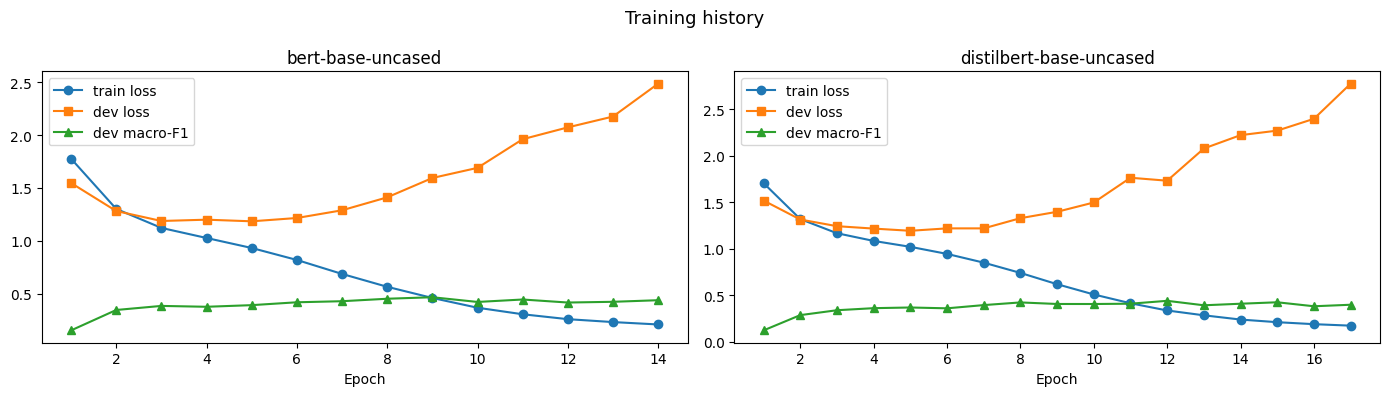

In [5]:
import os
import pandas as pd
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(run_dirs), figsize=(7 * len(run_dirs), 4), squeeze=False)

for ax, run_dir in zip(axes[0], run_dirs):
    history_path = os.path.join(run_dir, 'history.csv')
    if not os.path.exists(history_path):
        continue
    hist = pd.read_csv(history_path)
    ax.plot(hist['epoch'], hist['train_loss'],    label='train loss',    marker='o')
    ax.plot(hist['epoch'], hist['dev_loss'],      label='dev loss',      marker='s')
    ax.plot(hist['epoch'], hist['dev_macro_f1'],  label='dev macro-F1',  marker='^')
    ax.set_xlabel('Epoch')
    ax.set_title(os.path.basename(run_dir).replace('_', '-'))
    ax.legend()

plt.suptitle('Training history', fontsize=13)
plt.tight_layout()
plt.show()